# RF-DETR Large — Brain Tumor Segmentation

**Model:** RFDETRSegLarge (~35.7M params, resolution 560x560)

**Dataset:** Normalized merged dataset (4 sources, binary mask 0/1)

**Input:** Notebook output `dataset_normalized/` (images + masks đã chuẩn hóa)

## Cell 1 — Cài đặt RF-DETR & kiểm tra GPU

In [1]:
!pip install -q "rfdetr[train,loggers]" supervision pycocotools opencv-python-headless

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 106.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 98.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

## Cell 2 — Xác định đường dẫn dataset normalized

Dataset normalized nằm trong notebook output (Add Input > Notebook). Chạy cell này để tìm path tự động.

In [3]:
import os
from pathlib import Path

# Tim duong dan dataset normalized tu notebook output
NORMALIZED_DIR = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "dataset_normalized" in dirs:
        candidate = Path(root) / "dataset_normalized"
        if (candidate / "images").exists() and (candidate / "masks").exists():
            NORMALIZED_DIR = candidate
            break

if NORMALIZED_DIR is None:
    # Fallback: neu dataset da upload rieng
    for candidate in [
        Path("/kaggle/input/brain-tumor-segmentation-merged"),
        Path("/kaggle/input/datasets/ruby292/brain-tumor-segmentation-merged"),
    ]:
        if (candidate / "images").exists():
            NORMALIZED_DIR = candidate
            break

assert NORMALIZED_DIR is not None, "Khong tim thay dataset! Kiem tra lai Input."

IMAGES_DIR = NORMALIZED_DIR / "images"
MASKS_DIR = NORMALIZED_DIR / "masks"

n_images = len(list(IMAGES_DIR.glob("*")))
n_masks = len(list(MASKS_DIR.glob("*")))
print(f"Dataset path: {NORMALIZED_DIR}")
print(f"Images: {n_images}, Masks: {n_masks}, Match: {n_images == n_masks}")

Dataset path: /kaggle/input/notebooks/ruby292/rf-dert-large/dataset_normalized
Images: 15755, Masks: 15755, Match: True


## Cell 3 — Convert mask → COCO JSON format

RF-DETR cần dataset dạng COCO JSON (`_annotations.coco.json` trong mỗi split). Cell này:
1. Đọc ảnh + mask đã normalized (binary 0/1)
2. Split 80/10/10 (train/valid/test)
3. Tìm contour từ mask → polygon → COCO annotation
4. Lưu ra `/kaggle/working/dataset_coco/`

Tim thay 15755 cap anh-mask.

Kiem tra 3 cap dau:


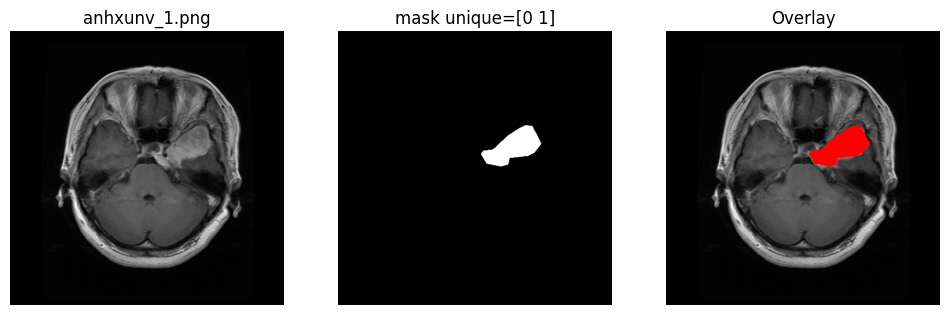

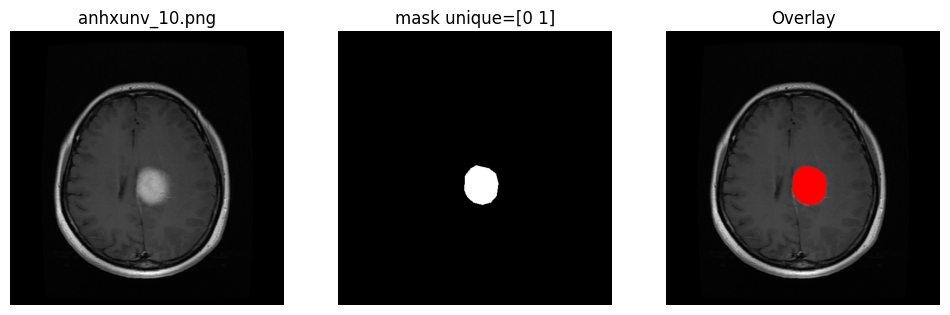

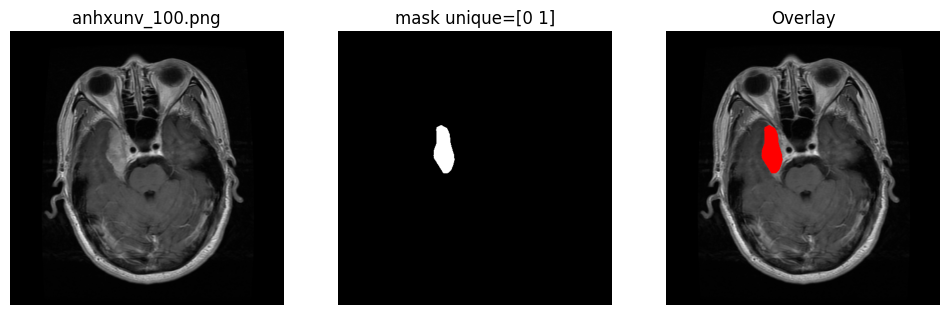

  train: 12604 samples
  valid: 1575 samples
  test: 1576 samples
  train: 12604 anh, 19952 annotations
  valid: 1575 anh, 2485 annotations
  test: 1576 anh, 2638 annotations

Dataset COCO tai: /kaggle/working/dataset_coco


In [4]:
import json
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

OUTPUT_DATASET_DIR = "/kaggle/working/dataset_coco"
CLASS_NAME = "tumor"
IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")

# === CACHE: bo qua neu da convert roi ===
_splits_expected = ("train", "valid", "test")
_cache_ok = all(
    os.path.exists(os.path.join(OUTPUT_DATASET_DIR, s, "_annotations.coco.json"))
    for s in _splits_expected
)

if _cache_ok:
    DATASET_DIR = OUTPUT_DATASET_DIR
    print(f"Da tim thay dataset COCO da convert tu lan chay truoc: {DATASET_DIR}")
    print("Bo qua buoc convert. Xoa thu muc nay roi chay lai neu muon convert lai.")
else:
    image_paths = sorted([str(f) for f in IMAGES_DIR.glob("*") if f.suffix.lower() in IMAGE_EXTENSIONS])
    mask_paths = sorted([str(f) for f in MASKS_DIR.glob("*") if f.suffix.lower() in IMAGE_EXTENSIONS])

    # Doi chieu ten file (mask co the co suffix _mask)
    img_dict = {Path(p).stem: p for p in image_paths}
    msk_dict = {}
    for p in mask_paths:
        stem = Path(p).stem
        # Bo suffix _mask neu co
        key = stem.replace("_mask", "") if "_mask" in stem else stem
        msk_dict[key] = p

    paired_keys = sorted(set(img_dict.keys()) & set(msk_dict.keys()))
    image_paths = [img_dict[k] for k in paired_keys]
    mask_paths = [msk_dict[k] for k in paired_keys]
    print(f"Tim thay {len(image_paths)} cap anh-mask.")

    # Kiem tra nhanh 3 cap
    print("\nKiem tra 3 cap dau:")
    for _img_path, _mask_path in list(zip(image_paths, mask_paths))[:3]:
        _img = cv2.cvtColor(cv2.imread(_img_path), cv2.COLOR_BGR2RGB)
        _mask = cv2.imread(_mask_path, cv2.IMREAD_GRAYSCALE)
        _overlay = _img.copy()
        _overlay[_mask > 0] = [255, 0, 0]
        _fig, _axes = plt.subplots(1, 3, figsize=(12, 4))
        _axes[0].imshow(_img); _axes[0].set_title(os.path.basename(_img_path)); _axes[0].axis("off")
        _axes[1].imshow(_mask, cmap="gray"); _axes[1].set_title(f"mask unique={np.unique(_mask)}"); _axes[1].axis("off")
        _axes[2].imshow(_overlay); _axes[2].set_title("Overlay"); _axes[2].axis("off")
        plt.show()

    # Split 80/10/10
    img_train, img_temp, mask_train, mask_temp = train_test_split(
        image_paths, mask_paths, test_size=0.2, random_state=42
    )
    img_val, img_test, mask_val, mask_test = train_test_split(
        img_temp, mask_temp, test_size=0.5, random_state=42
    )
    splits = {
        "train": list(zip(img_train, mask_train)),
        "valid": list(zip(img_val, mask_val)),
        "test": list(zip(img_test, mask_test)),
    }
    for name, pairs in splits.items():
        print(f"  {name}: {len(pairs)} samples")

    def mask_to_coco_annotations(mask_path, image_id, ann_id_start):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # Mask da normalized: 0=bg, 1=tumor -> nhan 255 de findContours
        binary = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask
        _, binary = cv2.threshold(binary, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        anns = []
        ann_id = ann_id_start
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            segmentation = cnt.flatten().tolist()
            if len(segmentation) < 6:
                continue
            anns.append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": 1,
                "bbox": [x, y, w, h],
                "area": float(cv2.contourArea(cnt)),
                "iscrowd": 0,
                "segmentation": [segmentation],
            })
            ann_id += 1
        return anns, ann_id

    for split_name, split_pairs in splits.items():
        split_dir = os.path.join(OUTPUT_DATASET_DIR, split_name)
        os.makedirs(split_dir, exist_ok=True)
        images_meta, annotations = [], []
        ann_id = 1
        for image_id, (img_path, mask_path) in enumerate(split_pairs, start=1):
            img = cv2.imread(img_path)
            h, w = img.shape[:2]
            fname = f"{image_id:06d}.jpg"
            cv2.imwrite(os.path.join(split_dir, fname), img)
            images_meta.append({"id": image_id, "file_name": fname, "width": w, "height": h})
            anns, ann_id = mask_to_coco_annotations(mask_path, image_id, ann_id)
            annotations.extend(anns)

        coco_dict = {
            "info": {"description": "Brain tumor merged dataset (normalized), converted to COCO"},
            "licenses": [],
            "images": images_meta,
            "categories": [{"id": 1, "name": CLASS_NAME, "supercategory": "none"}],
            "annotations": annotations,
        }
        with open(os.path.join(split_dir, "_annotations.coco.json"), "w") as f:
            json.dump(coco_dict, f)
        print(f"  {split_name}: {len(images_meta)} anh, {len(annotations)} annotations")

    DATASET_DIR = OUTPUT_DATASET_DIR
    print(f"\nDataset COCO tai: {DATASET_DIR}")

## Cell 4 — Cấu hình model RF-DETR Seg Large

**RFDETRSegLarge** (~35.7M params, resolution 560x560). Batch size = 4 vì Large model tốn VRAM hơn Small trên T4 16GB.

In [5]:
from rfdetr import RFDETRSegLarge

OUTPUT_DIR = "/kaggle/working/rfdetr_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EPOCHS = 60
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2  # effective batch = 4 x 2 = 8
CHECKPOINT_INTERVAL = 5

NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 4
PROGRESS_BAR = "tqdm"
EVAL_INTERVAL = 3

MULTI_SCALE = False
EXPANDED_SCALES = False

resume_path = None
last_ckpt = os.path.join(OUTPUT_DIR, "last.ckpt")
if os.path.exists(last_ckpt):
    resume_path = last_ckpt
    print(f"Tim thay checkpoint truoc do, se RESUME tu: {resume_path}")
else:
    print("Khong co checkpoint truoc do - train tu dau.")

best_weights_path = os.path.join(OUTPUT_DIR, "best_weights.pth")
last_weights_path = os.path.join(OUTPUT_DIR, "last_weights.ckpt")

print(f"NUM_WORKERS = {NUM_WORKERS}")
print(f"MODEL: RFDETRSegLarge (~35.7M params, resolution 560x560)")
print(f"BATCH_SIZE={BATCH_SIZE}, GRAD_ACCUM={GRAD_ACCUM_STEPS} -> effective batch = {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"EVAL_INTERVAL={EVAL_INTERVAL}, MULTI_SCALE={MULTI_SCALE}")

model = RFDETRSegLarge()

Khong co checkpoint truoc do - train tu dau.
NUM_WORKERS = 4
MODEL: RFDETRSegLarge (~35.7M params, resolution 560x560)
BATCH_SIZE=4, GRAD_ACCUM=2 -> effective batch = 8
EVAL_INTERVAL=3, MULTI_SCALE=False
[2026-07-15 15:22:22] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-seg-large.pt


/usr/local/lib/python3.12/dist-packages/rfdetr/models/weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


/root/.roboflow/models/rf-detr-seg-large.pt:   0%|          | 0.00/138M [00:00<?, ?iB/s]

[2026-07-15 15:22:23] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-seg-large.pt


[2026-07-15 15:22:23] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-15 15:22:23] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-15 15:22:24] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-seg-large.pt already exists with correct MD5 hash.


[2026-07-15 15:22:25] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.
[2026-07-15 15:22:25] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-seg-large.pt' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


## Cell 5 — Checkpoint Watcher

Thread chạy song song, tự động copy best/last checkpoint mỗi 20s. Đảm bảo không mất weights nếu notebook bị ngắt giữa chừng.

In [6]:
import csv
import shutil
import threading
import time
from datetime import datetime


class CheckpointWatcher:
    def __init__(self, output_dir, total_epochs, interval=20):
        self.output_dir = output_dir
        self.total_epochs = total_epochs
        self.interval = interval
        self._stop_event = threading.Event()
        self._thread = None
        self._last_best_mtime = 0.0
        self._last_ckpt_mtime = 0.0
        self._last_metrics_rows = 0
        self._start_time = time.time()

    def _sync_best_weights(self):
        candidates = [
            os.path.join(self.output_dir, name)
            for name in ("checkpoint_best_total.pth", "checkpoint_best_ema.pth", "checkpoint_best_regular.pth")
            if os.path.exists(os.path.join(self.output_dir, name))
        ]
        if not candidates:
            return
        newest = max(candidates, key=os.path.getmtime)
        mtime = os.path.getmtime(newest)
        if mtime > self._last_best_mtime:
            shutil.copy2(newest, os.path.join(self.output_dir, "best_weights.pth"))
            self._last_best_mtime = mtime

    def _sync_last_weights(self):
        last_ckpt = os.path.join(self.output_dir, "last.ckpt")
        if os.path.exists(last_ckpt):
            mtime = os.path.getmtime(last_ckpt)
            if mtime > self._last_ckpt_mtime:
                shutil.copy2(last_ckpt, os.path.join(self.output_dir, "last_weights.ckpt"))
                self._last_ckpt_mtime = mtime

    def _print_progress(self):
        metrics_path = os.path.join(self.output_dir, "metrics.csv")
        if not os.path.exists(metrics_path):
            return
        try:
            with open(metrics_path, newline="") as f:
                rows = list(csv.DictReader(f))
        except Exception:
            return
        if len(rows) <= self._last_metrics_rows:
            return
        self._last_metrics_rows = len(rows)
        last_row = rows[-1]

        def fmt(key):
            val = last_row.get(key, "")
            try:
                return f"{float(val):.4f}"
            except (TypeError, ValueError):
                return "-"

        epoch = last_row.get("epoch", "?")
        elapsed_min = (time.time() - self._start_time) / 60
        print(
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"epoch {epoch}/{self.total_epochs} | {elapsed_min:.1f} min | "
            f"train/loss={fmt('train/loss')} | "
            f"val/mAP_50_95={fmt('val/mAP_50_95')} | "
            f"val/segm_mAP_50_95={fmt('val/segm_mAP_50_95')} | "
            f"val/F1={fmt('val/F1')}"
        )

    def _run_loop(self):
        while not self._stop_event.is_set():
            try:
                self._sync_best_weights()
                self._sync_last_weights()
                self._print_progress()
            except Exception as exc:
                print(f"[Watcher] loi tam thoi: {exc}")
            self._stop_event.wait(self.interval)

    def start(self):
        self._thread = threading.Thread(target=self._run_loop, daemon=True)
        self._thread.start()
        print(f"[Watcher] da bat dau - kiem tra moi {self.interval}s.")
        return self

    def stop(self):
        self._stop_event.set()
        if self._thread is not None:
            self._thread.join(timeout=10)
        self._sync_best_weights()
        self._sync_last_weights()
        self._print_progress()
        print("[Watcher] da dung.")

## Cell 6 — Train

Bật GPU T4 + Internet trước khi chạy.

In [ ]:
watcher = CheckpointWatcher(OUTPUT_DIR, total_epochs=EPOCHS, interval=20).start()

try:
    model.train(
        dataset_dir=DATASET_DIR,
        output_dir=OUTPUT_DIR,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        lr=1e-4,
        devices=1,
        strategy="auto",
        checkpoint_interval=CHECKPOINT_INTERVAL,
        use_ema=True,
        early_stopping=True,
        early_stopping_patience=10,
        resume=resume_path,
        tensorboard=True,
        run_test=True,
        progress_bar=PROGRESS_BAR,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR,
        eval_interval=EVAL_INTERVAL,
        multi_scale=MULTI_SCALE,
        expanded_scales=EXPANDED_SCALES,
    )
finally:
    watcher.stop()

[Watcher] da bat dau - kiem tra moi 20s.


[2026-07-15 15:24:09] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-15 15:24:09] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-15 15:24:10] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-seg-large.pt already exists with correct MD5 hash.


[2026-07-15 15:24:10] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 1. The detection head will be re-initialized to 1 classes.
[2026-07-15 15:24:10] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.
[2026-07-15 15:24:10] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-seg-large.pt' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experim

[2026-07-15 15:24:26] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 504
[2026-07-15 15:24:26] [INFO] rf-detr - Built 1 Albumentations transforms from config


...

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ LWDETR       │ 35.6 M │ train │     0 │
│ 1 │ criterion   │ SetCriterion │      0 │ train │     0 │
│ 2 │ postprocess │ PostProcess  │      0 │ train │     0 │
└───┴─────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 35.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 35.6 M                                                                                               
Total estimated model params size (MB): 142.215                                                                    
Modules in train mode: 535                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

[15:27:47] epoch 0/60 | 3.7 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:30:47] epoch 0/60 | 6.7 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:33:47] epoch 0/60 | 9.7 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:36:47] epoch 0/60 | 12.7 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:40:07] epoch 0/60 | 16.0 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:43:07] epoch 0/60 | 19.0 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:46:07] epoch 0/60 | 22.0 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:49:07] epoch 0/60 | 25.0 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:52:07] epoch 0/60 | 28.0 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15:55:07] epoch 0/60 | 31.0 min | train/loss=- | val/mAP_50_95=- | val/segm_mAP_50_95=- | val/F1=-
[15

## Cell 7 — Lưu best/last weights

In [ ]:
import glob

best_total_path = os.path.join(OUTPUT_DIR, "checkpoint_best_total.pth")
if os.path.exists(best_total_path):
    shutil.copy2(best_total_path, best_weights_path)
    print(f"Best weights (chinh thuc): {best_weights_path}")
elif os.path.exists(best_weights_path):
    print(f"Dung best_weights.pth tu watcher: {best_weights_path}")
else:
    print("CANH BAO: chua thay best_weights.pth")

last_ckpt_path = os.path.join(OUTPUT_DIR, "last.ckpt")
if os.path.exists(last_ckpt_path):
    shutil.copy2(last_ckpt_path, last_weights_path)
    ckpt = torch.load(last_ckpt_path, map_location="cpu", weights_only=False)
    last_epoch = ckpt.get("epoch", None)
    suffix = f"{last_epoch:02d}" if isinstance(last_epoch, int) else "unknown"
    last_named = os.path.join(OUTPUT_DIR, f"last_checkpoint_epoch{suffix}.ckpt")
    shutil.copy2(last_ckpt_path, last_named)
    print(f"Last weights: {last_weights_path}")
    print(f"Last checkpoint: {last_named}")
else:
    print("CANH BAO: chua thay last.ckpt")

print("\nCheckpoints:")
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, "*"))):
    if os.path.isfile(f):
        size_mb = os.path.getsize(f) / 1e6
        print(f"  {os.path.basename(f):40s} {size_mb:8.1f} MB")

## Cell 8 — Đánh giá (mAP, F1, learning curve)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_path = os.path.join(OUTPUT_DIR, "metrics.csv")
df = pd.read_csv(metrics_path)

# Learning curve
loss_cols = [c for c in ["epoch", "train/loss", "val/loss"] if c in df.columns]
if len(loss_cols) >= 2:
    loss_df = df[loss_cols].groupby("epoch", as_index=False).mean()
    plt.figure(figsize=(8, 4))
    if "train/loss" in loss_df.columns:
        plt.plot(loss_df["epoch"], loss_df["train/loss"], marker="o", label="train/loss")
    if "val/loss" in loss_df.columns:
        plt.plot(loss_df["epoch"], loss_df["val/loss"], marker="o", label="val/loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Learning curve")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

# mAP theo epoch
key_cols = [c for c in [
    "epoch", "val/mAP_50_95", "val/mAP_50", "val/mAP_75", "val/mAR",
    "val/segm_mAP_50_95", "val/segm_mAP_50",
    "val/F1", "val/precision", "val/recall",
] if c in df.columns]
display(df[key_cols].dropna(how="all", subset=key_cols[1:]))

plot_df = df.dropna(subset=["val/mAP_50_95"]) if "val/mAP_50_95" in df.columns else None
if plot_df is not None and len(plot_df) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["epoch"], plot_df["val/mAP_50_95"], marker="o", label="val/mAP_50_95")
    if "val/segm_mAP_50_95" in plot_df.columns:
        plt.plot(plot_df["epoch"], plot_df["val/segm_mAP_50_95"], marker="o", label="val/segm_mAP_50_95")
    plt.xlabel("epoch"); plt.ylabel("mAP"); plt.title("mAP theo epoch")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

# Test set
test_cols = [c for c in df.columns if c.startswith("test/")]
test_rows = df[test_cols].dropna(how="all") if test_cols else df.iloc[0:0]
print("\n=== KET QUA TEST SET ===")
if len(test_rows) > 0:
    final_test = test_rows.iloc[-1]
    for col in sorted(test_cols):
        val = final_test.get(col)
        if pd.notna(val):
            print(f"  {col:28s}: {val:.4f}")
else:
    print("  Chua co ket qua test.")

## Cell 9 — Inference demo

In [ ]:
import supervision as sv
from PIL import Image

inference_model = RFDETRSegLarge(pretrain_weights=best_weights_path)

test_images = (
    glob.glob(os.path.join(DATASET_DIR, "test", "*.jpg"))
    + glob.glob(os.path.join(DATASET_DIR, "test", "*.png"))
)
if test_images:
    sample_image_path = test_images[0]
    detections = inference_model.predict(sample_image_path, threshold=0.5)
    image = Image.open(sample_image_path)
    annotated = sv.MaskAnnotator().annotate(image.copy(), detections)
    annotated = sv.LabelAnnotator().annotate(annotated, detections)
    annotated
else:
    print("Khong tim thay anh test.")